# PRA Synthetic Scaling Experiments

This notebook exercises the complete PRA path with deterministic synthetic datasets:
`PRADataset` -> `PRADataModule` -> `DataLoader` -> cache construction ->
`train_pra_model` -> metric history -> evaluation.

Every operation is packaged as a reusable function. The cell immediately following
each function runs the lightweight `DEFAULT_SIZE = 3` workflow. The final section
provides independent workload cells for 30, 300, 3,000, and 30,000 examples.

In [1]:
from collections import defaultdict
from pathlib import Path
import json
import math
import random
import sys

repo = Path.cwd()
if repo.name == "nb":
    repo = repo.parent
sys.path.insert(0, str(repo / "src"))
sys.path.insert(0, str(repo))

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import display

from data.datamodules import PRADataModule
from data.datasets import SyntheticMemoryQADataset
from pra_torch.cache_services import build_cache_from_metadata
from pra_torch.config import PRAConfig, TrainConfig
from pra_torch.eval import run_evaluation
from pra_torch.model import TinyPRAModel
from pra_torch.pra_train import train_pra_model

## Runtime And Experiment Controls

In [2]:
def configure_notebook(default_size=3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return {
        "default_size": int(default_size),
        "scaling_sizes": (30, 300, 3_000, 30_000),
        "run_scaling_experiments": False,
        "write_images_to_disk": False,
        "seed": 7,
        "device": device,
        "python": sys.version.split()[0],
        "torch": torch.__version__,
        "torch_cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "compute_capability": (
            torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None
        ),
    }

In [3]:
settings = configure_notebook(default_size=3)
DEFAULT_SIZE = settings["default_size"]
SCALING_SIZES = settings["scaling_sizes"]
RUN_SCALING_EXPERIMENTS = settings["run_scaling_experiments"]
WRITE_IMAGES_TO_DISK = settings["write_images_to_disk"]
settings

{'default_size': 3,
 'scaling_sizes': (30, 300, 3000, 30000),
 'run_scaling_experiments': False,
 'write_images_to_disk': False,
 'seed': 7,
 'device': 'cuda',
 'python': '3.10.11',
 'torch': '2.12.1+cu126',
 'torch_cuda': '12.6',
 'cuda_available': True,
 'gpu': 'NVIDIA GeForce GTX 950M',
 'compute_capability': (5, 0)}

## Generate A Bounded Synthetic Memory Dataset

Dataset size controls the number of question examples, not the number of references.
A fixed bank of eight facts keeps PRA cache cost bounded while templates, target facts,
and distractor tokens vary deterministically. This makes comparisons across sizes useful
without attaching tens of thousands of references to every sample.

In [4]:
def generate_synthetic_dataset(size, seed=7, root=None):
    size = int(size)
    if size < 3:
        raise ValueError("Synthetic experiments require at least three examples.")

    root = Path(root or repo / "out" / "notebook_synthetic" / f"size_{size}" / "data")
    stage_dir = root / "stage0_synthetic_memory"
    stage_dir.mkdir(parents=True, exist_ok=True)

    facts = [
        ("cat", "hunts mice"),
        ("bee", "makes honey"),
        ("CODE34", "is the dog's secret code"),
        ("owl", "is active at night"),
        ("dolphin", "is an aquatic mammal"),
        ("cactus", "stores water in its stem"),
        ("Mars", "is called the red planet"),
        ("copper", "conducts electricity well"),
    ]
    templates = [
        "What {clue}?",
        "Name what {clue}.",
        "Which answer matches: {clue}?",
        "From the referenced facts, identify what {clue}.",
    ]
    documents = []
    references = []
    for index, (answer, clue) in enumerate(facts, start=1):
        uri = f"memory://synthetic/fact-{index}"
        documents.append(
            {
                "id": f"doc-{index}",
                "uri": uri,
                "title": f"Synthetic fact {index}",
                "text": f"The answer is {answer}; it {clue}.",
            }
        )
        references.append(
            {
                "id": index,
                "token": f"<REF_{index}>",
                "uri": uri,
                "summary": f"Fact about {answer}.",
                "metadata": {"stage": 0, "synthetic": True},
            }
        )

    rng = random.Random(seed)
    questions = []
    reference_ids = list(range(1, len(facts) + 1))
    for index in range(size):
        target_id = index % len(facts) + 1
        answer, clue = facts[target_id - 1]
        distractors = rng.sample([ref for ref in reference_ids if ref != target_id], 2)
        prompt_refs = [target_id, *distractors]
        rng.shuffle(prompt_refs)
        prompt = templates[(index // len(facts)) % len(templates)].format(clue=clue)
        prompt += " " + " ".join(f"<REF_{ref}>" for ref in prompt_refs)
        questions.append(
            {
                "id": f"synthetic-{size}-{index:06d}",
                "prompt": prompt,
                "answer": answer,
                "expected_ref_ids": [target_id],
                "expected_anchors": [],
            }
        )

    def write_jsonl(path, rows):
        with path.open("w", encoding="utf-8") as stream:
            for row in rows:
                stream.write(json.dumps(row) + "\n")

    write_jsonl(stage_dir / "documents.jsonl", documents)
    write_jsonl(stage_dir / "references.jsonl", references)
    write_jsonl(stage_dir / "questions.jsonl", questions)
    return {
        "size": size,
        "data_dir": root,
        "stage_dir": stage_dir,
        "references": len(references),
        "templates": len(templates),
        "sample_question": questions[0],
    }

In [5]:
default_data = generate_synthetic_dataset(DEFAULT_SIZE, settings["seed"])
default_data

{'size': 3,
 'data_dir': WindowsPath('D:/git/rd/pdattention/out/notebook_synthetic/size_3/data'),
 'stage_dir': WindowsPath('D:/git/rd/pdattention/out/notebook_synthetic/size_3/data/stage0_synthetic_memory'),
 'references': 8,
 'templates': 4,
 'sample_question': {'id': 'synthetic-3-000000',
  'prompt': 'What hunts mice? <REF_3> <REF_1> <REF_4>',
  'answer': 'cat',
  'expected_ref_ids': [1],
  'expected_anchors': []}}

## Inspect A Generated Sample

In [6]:
def inspect_synthetic_sample(dataset_info):
    dataset = SyntheticMemoryQADataset(dataset_info["data_dir"], max_examples=dataset_info["size"])
    sample = dataset[0]
    table = dataset.build_reference_table(sample)
    return {
        "dataset_size": len(dataset),
        "id": sample.id,
        "question": sample.question,
        "answer": sample.answer,
        "target_reference_ids": sample.target_reference_ids,
        "reference_tokens": [handle.token for handle in table.all()],
        "reference_uris": [handle.uri for handle in table.all()],
    }

In [7]:
default_sample = inspect_synthetic_sample(default_data)
default_sample

{'dataset_size': 3,
 'id': 'synthetic-3-000000',
 'question': 'What hunts mice? <REF_3> <REF_1> <REF_4>',
 'answer': 'cat',
 'target_reference_ids': [1],
 'reference_tokens': ['<REF_1>',
  '<REF_2>',
  '<REF_3>',
  '<REF_4>',
  '<REF_5>',
  '<REF_6>',
  '<REF_7>',
  '<REF_8>'],
 'reference_uris': ['memory://synthetic/fact-1',
  'memory://synthetic/fact-2',
  'memory://synthetic/fact-3',
  'memory://synthetic/fact-4',
  'memory://synthetic/fact-5',
  'memory://synthetic/fact-6',
  'memory://synthetic/fact-7',
  'memory://synthetic/fact-8']}

## Create Reusable DataLoaders

In [8]:
def build_datamodule(dataset_info, batch_size=2, max_seq_len=96, seed=7):
    torch.manual_seed(seed)
    datamodule = PRADataModule(
        dataset_stage="stage0_synthetic_memory",
        data_dir=dataset_info["data_dir"],
        max_examples=dataset_info["size"],
        batch_size=batch_size,
        max_seq_len=max_seq_len,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    ).load()
    batch = next(iter(datamodule.train_loader()))
    summary = {
        "total": len(datamodule.dataset),
        "train": len(datamodule.train_dataset),
        "validation": len(datamodule.val_dataset),
        "test": len(datamodule.test_dataset),
        "vocab_size": datamodule.tokenizer.vocab_size,
        "batch_shape": tuple(batch["input_ids"].shape),
        "first_question": batch["metadata"][0]["question"],
    }
    return datamodule, batch, summary

In [9]:
default_dm, default_batch, default_loader_summary = build_datamodule(
    default_data, batch_size=2, seed=settings["seed"]
)
default_loader_summary

{'total': 3,
 'train': 1,
 'validation': 1,
 'test': 1,
 'vocab_size': 106,
 'batch_shape': (1, 44),
 'first_question': "What is the dog's secret code? <REF_6> <REF_3> <REF_1>"}

## Verify Reference Tokens Remain Atomic

In [10]:
def inspect_reference_tokenization(datamodule, text="Use <REF_1> before <REF_2>."):
    ids = datamodule.tokenizer.encode(text)
    decoded = datamodule.tokenizer.decode(ids)
    return {
        "text": text,
        "ids": ids,
        "decoded": decoded,
        "ref_1_id": datamodule.tokenizer.stoi["<REF_1>"],
        "ref_2_id": datamodule.tokenizer.stoi["<REF_2>"],
        "round_trip_ok": decoded == text,
    }

In [11]:
default_tokenization = inspect_reference_tokenization(default_dm)
default_tokenization

{'text': 'Use <REF_1> before <REF_2>.',
 'ids': [58, 88, 74, 5, 101, 5, 71, 74, 75, 84, 87, 74, 5, 102, 19],
 'decoded': 'Use <REF_1> before <REF_2>.',
 'ref_1_id': 101,
 'ref_2_id': 102,
 'round_trip_ok': True}

## Smoke-Test Cache Construction And Backpropagation

In [12]:
def run_single_batch_smoke(datamodule, batch, device):
    cfg = PRAConfig(
        vocab_size=datamodule.tokenizer.vocab_size,
        max_seq_len=96,
        d_model=32,
        n_heads=4,
        n_layers=2,
        pra_layer_ids=(0, 1),
        batch_size=batch["input_ids"].shape[0],
        device=device,
    )
    model = TinyPRAModel(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    cache = build_cache_from_metadata(model, datamodule.tokenizer, batch["metadata"], device)
    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)
    logits = model(input_ids)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1), ignore_index=0)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return {
        "loss": float(loss.detach().cpu()),
        "cache_entries": len(cache.entries),
        "model_parameters": sum(parameter.numel() for parameter in model.parameters()),
        "logits_shape": tuple(logits.shape),
        "device": next(model.parameters()).device.type,
    }

In [13]:
default_smoke = run_single_batch_smoke(default_dm, default_batch, settings["device"])
default_smoke

{'loss': 4.627342224121094,
 'cache_entries': 8,
 'model_parameters': 37440,
 'logits_shape': (1, 44, 106),
 'device': 'cuda'}

## Scale Model Capacity And Epochs

The schedule increases model capacity only when data volume can support it. Epochs fall
with size because optimizer updates still increase sharply: the 30,000-example workload
gets far more updates in three epochs than the 30-example workload gets in fifteen.
`DEFAULT_SIZE = 3` intentionally receives extra epochs so it can serve as an overfit smoke
test; it is too small to establish generalization performance.

In [14]:
def experiment_policy(size):
    size = int(size)
    if size <= 3:
        policy = dict(d_model=32, n_layers=2, n_heads=4, batch_size=2, epochs=20, lr=1e-3)
    elif size <= 30:
        policy = dict(d_model=32, n_layers=2, n_heads=4, batch_size=8, epochs=40, lr=8e-4)
    elif size <= 300:
        policy = dict(d_model=64, n_layers=3, n_heads=4, batch_size=16, epochs=12, lr=5e-4)
    elif size <= 3_000:
        policy = dict(d_model=96, n_layers=4, n_heads=4, batch_size=32, epochs=5, lr=3e-4)
    else:
        policy = dict(d_model=128, n_layers=4, n_heads=4, batch_size=32, epochs=3, lr=3e-4)
    train_examples = size if size < 3 else max(1, int(size * 0.8))
    policy["estimated_optimizer_steps"] = math.ceil(train_examples / policy["batch_size"]) * policy["epochs"]
    policy["max_seq_len"] = 96
    return policy

In [15]:
default_policy = experiment_policy(DEFAULT_SIZE)
default_policy

{'d_model': 32,
 'n_layers': 2,
 'n_heads': 4,
 'batch_size': 2,
 'epochs': 20,
 'lr': 0.001,
 'estimated_optimizer_steps': 20,
 'max_seq_len': 96}

## Train One Synthetic Workload

In [16]:
def train_synthetic_workload(size, settings, show_progress=True):
    dataset_info = generate_synthetic_dataset(size, settings["seed"])
    policy = experiment_policy(size)
    datamodule, _, loader_summary = build_datamodule(
        dataset_info,
        batch_size=policy["batch_size"],
        max_seq_len=policy["max_seq_len"],
        seed=settings["seed"],
    )
    cfg = PRAConfig(
        vocab_size=datamodule.tokenizer.vocab_size,
        max_seq_len=policy["max_seq_len"],
        d_model=policy["d_model"],
        n_heads=policy["n_heads"],
        n_layers=policy["n_layers"],
        pra_layer_ids=tuple(range(policy["n_layers"])),
        dropout=0.0,
        batch_size=policy["batch_size"],
        lr=policy["lr"],
        device=settings["device"],
    )
    steps_per_epoch = max(1, math.ceil(len(datamodule.train_dataset) / policy["batch_size"]))
    train_config = TrainConfig(
        experiment_name=f"synthetic_size_{size}",
        output_dir=str(repo / "out" / "notebook_scaling"),
        seed=settings["seed"],
        device=settings["device"],
        epochs=policy["epochs"],
        batch_size=policy["batch_size"],
        learning_rate=policy["lr"],
        weight_decay=0.0,
        eval_every_steps=max(steps_per_epoch, 1),
        save_every_steps=max(steps_per_epoch * policy["epochs"], 1),
        log_every_steps=max(steps_per_epoch // 5, 1),
        use_tensorboard=False,
        save_metric_plots=settings["write_images_to_disk"],
        mixed_precision=(
            settings["device"] == "cuda"
            and settings["compute_capability"] is not None
            and settings["compute_capability"][0] >= 7
        ),
        dataset_stage="stage0_synthetic_memory",
        data_dir=str(dataset_info["data_dir"]),
        max_examples=size,
        max_seq_len=policy["max_seq_len"],
        shuffle=True,
    )
    result = train_pra_model(cfg=cfg, train_config=train_config, datamodule=datamodule)
    result.update(
        {
            "size": size,
            "policy": policy,
            "cfg": cfg,
            "train_config": train_config,
            "datamodule": datamodule,
            "loader_summary": loader_summary,
            "parameter_count": sum(parameter.numel() for parameter in result["model"].parameters()),
        }
    )
    if show_progress:
        print(
            f"size={size:,} parameters={result['parameter_count']:,} "
            f"epochs={policy['epochs']} optimizer_steps={result['global_step']} "
            f"test_loss={result['test_metrics'].get('loss', float('nan')):.4f} "
            f"test_accuracy={result['test_metrics'].get('answer_accuracy', 0.0):.2%}"
        )
    return result

In [17]:
default_result = train_synthetic_workload(DEFAULT_SIZE, settings)

[config] TrainConfig(experiment_name='synthetic_size_3', output_dir='D:\\git\\rd\\pdattention\\out\\notebook_scaling', seed=7, device='cuda', dtype='float32', epochs=20, max_steps=None, batch_size=2, grad_accum_steps=1, learning_rate=0.001, weight_decay=0.0, warmup_steps=0, max_grad_norm=1.0, eval_every_steps=1, save_every_steps=20, log_every_steps=1, num_workers=0, pin_memory=False, persistent_workers=False, resume_from=None, use_tensorboard=False, save_metric_plots=False, use_wandb=False, wandb_project='transformer-experiments', use_clearml=False, clearml_project='Transformer Experiments', mixed_precision=False, early_stopping_patience=None, dataset_stage='stage0_synthetic_memory', data_dir='D:\\git\\rd\\pdattention\\out\\notebook_synthetic\\size_3\\data', max_examples=3, max_seq_len=96, shuffle=True, resolver_config=ResolverServiceConfig(type='in_memory', options={}), cache_config=CacheServiceConfig(type='simple', options={}))


epoch 1/20:   0%|          | 0/1 [00:00<?, ?it/s]

[train_batch step=1] train_loss=4.6273 perplexity=102.2420 learning_rate=0.0010 grad_norm=2.3162 examples_per_second=9.8016 tokens_per_second=431.2707 gpu_memory_allocated=16.9902 train_batch_duration_seconds=0.1002 retrieval_reference_hit_at_1=0.0000 retrieval_reference_hit_at_k=0.0000 retrieval_reference_recall_at_k=0.0000 retrieval_reference_precision_at_k=0.0000 retrieval_reference_f1_at_k=0.0000 retrieval_reference_mrr=0.0000 retrieval_reference_ndcg=0.0000 retrieval_reference_selected_count=0.0000 memory_available_reference_count=8.0000 memory_available_chunk_count=8.0000 cache_reference_token_count=354.0000 retrieval_selected_reference_count=0.0000 retrieval_selected_chunk_count=0.0000 memory_selected_token_count=0.0000 memory_selected_reference_fraction=0.0000 memory_selected_chunk_fraction=0.0000 memory_selected_token_fraction=0.0000 retrieval_routing_score_mean=0.0000 retrieval_routing_score_max=0.0000 retrieval_zero_chunk_fraction=1.0000 memory_retrieved_chunk_attended_fract

epoch 1/20:   0%|          | 0/1 [00:00<?, ?it/s, step=1, loss=4.63, lr=0.001, ex/s=9.8, tok/s=431, val=4.72]

epoch 1/20: 100%|██████████| 1/1 [00:00<00:00,  4.31it/s, step=1, loss=4.63, lr=0.001, ex/s=9.8, tok/s=431, val=4.72]

...

epoch 20/20:   0%|          | 0/1 [00:00<?, ?it/s, step=20, loss=2.21, lr=0.001, ex/s=17.1, tok/s=751, val=4.43]

epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  4.85it/s, step=20, loss=2.21, lr=0.001, ex/s=17.1, tok/s=751, val=4.43]

epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  4.83it/s, step=20, loss=2.21, lr=0.001, ex/s=17.1, tok/s=751, val=4.43]

[train_epoch step=20] train_loss=2.2074 perplexity=9.0918 learning_rate=0.0010 grad_norm=1.9287 examples_per_second=4.7913 tokens_per_second=210.8150 gpu_memory_allocated=16.9902 train_batch_duration_seconds=0.0565 retrieval_reference_hit_at_1=0.0000 retrieval_reference_hit_at_k=0.0000 retrieval_reference_recall_at_k=0.0000 retrieval_reference_precision_at_k=0.0000 retrieval_reference_f1_at_k=0.0000 retrieval_reference_mrr=0.0000 retrieval_reference_ndcg=0.0000 retrieval_reference_selected_count=0.0000 memory_available_reference_count=8.0000 memory_available_chunk_count=8.0000 cache_reference_token_count=354.0000 retrieval_selected_reference_count=0.0000 retrieval_selected_chunk_count=0.0000 memory_selected_token_count=0.0000 memory_selected_reference_fraction=0.0000 memory_selected_chunk_fraction=0.0000 memory_selected_token_fraction=0.0000 retrieval_routing_score_mean=0.0000 retrieval_routing_score_max=0.0000 retrieval_zero_chunk_fraction=1.0000 memory_retrieved_chunk_attended_fracti

size=3 parameters=37,440 epochs=20 optimizer_steps=20 test_loss=4.4048 test_accuracy=0.00%


## Plot Batch-Wise And Epoch-Wise Progress

In [18]:
def plot_training_progress(result, write_to_disk=False):
    metrics_path = result["state"].run_dir / "metrics.json"
    payload = json.loads(metrics_path.read_text(encoding="utf-8"))
    records = payload["records"]
    by_split = defaultdict(list)
    for record in records:
        by_split[record["split"]].append(record)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    batch_records = by_split["train_batch"]
    axes[0].plot(
        [record.get("batch_step", record["step"]) for record in batch_records],
        [record["metrics"]["train_loss"] for record in batch_records],
        linewidth=1.2,
    )
    axes[0].set(title="Batch-wise training loss", xlabel="batch step", ylabel="loss")

    for split, metric, label in (
        ("train_epoch", "train_loss", "train"),
        ("val_epoch", "loss", "validation"),
    ):
        values = by_split[split]
        axes[1].plot(
            [record.get("epoch", record["step"]) for record in values],
            [record["metrics"][metric] for record in values],
            marker="o",
            label=label,
        )
    axes[1].set(title="Epoch-wise loss", xlabel="epoch", ylabel="loss")
    axes[1].legend()
    for axis in axes:
        axis.grid(True, alpha=0.3)
    fig.suptitle(f"Synthetic PRA training: {result['size']:,} examples")
    fig.tight_layout()
    if write_to_disk:
        output_path = result["state"].run_dir / "notebook_training_progress.png"
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"wrote {output_path}")
    display(fig)
    plt.close(fig)
    return {
        "train_batches": len(batch_records),
        "train_epochs": len(by_split["train_epoch"]),
        "validation_epochs": len(by_split["val_epoch"]),
        "metrics_path": metrics_path,
    }

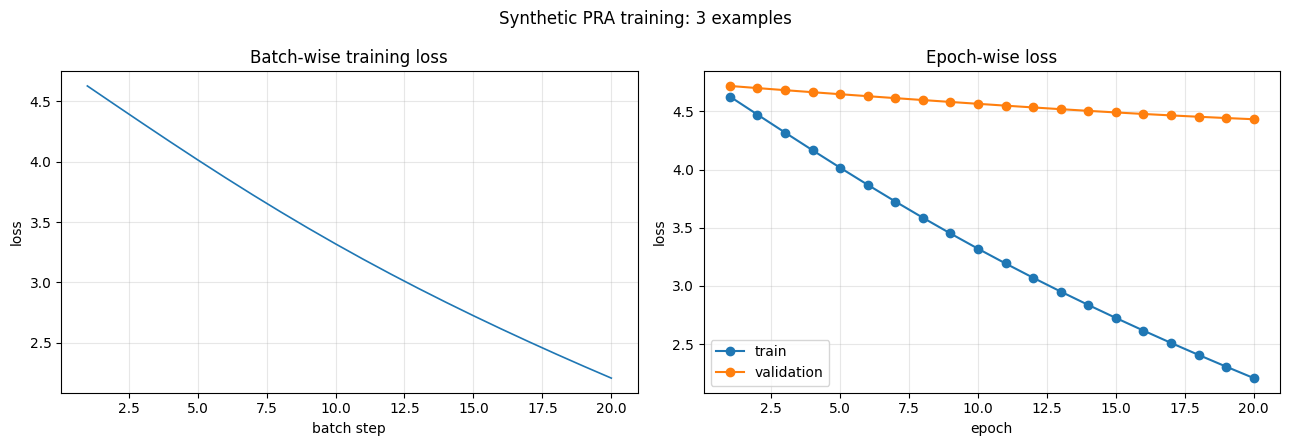

{'train_batches': 20,
 'train_epochs': 20,
 'validation_epochs': 20,
 'metrics_path': WindowsPath('D:/git/rd/pdattention/out/notebook_scaling/synthetic_size_3/metrics.json')}

In [19]:
default_progress = plot_training_progress(
    default_result, write_to_disk=WRITE_IMAGES_TO_DISK
)
default_progress

## Evaluate The Default Model Against Context Baselines

In [20]:
def evaluate_trained_workload(result, max_new_tokens=12):
    cfg = result["cfg"]
    checkpoint = result["state"].checkpoint.latest_path
    return run_evaluation(
        ckpt=str(checkpoint),
        device=result["state"].device,
        datamodule=result["datamodule"],
        max_new_tokens=max_new_tokens,
        max_seq_len=cfg.max_seq_len,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        n_vanilla_layers=cfg.n_vanilla_layers,
        n_mixed_layers=cfg.n_mixed_layers,
        dropout=cfg.dropout,
        pra_layer_ids=cfg.pra_layer_ids,
        top_k_refs=cfg.top_k_refs,
        trigger_threshold=cfg.trigger_threshold,
        use_cross_attention_memory=cfg.use_cross_attention_memory,
        use_concat_memory=cfg.use_concat_memory,
        memory_alpha=cfg.memory_alpha,
    )

In [21]:
default_evaluation = evaluate_trained_workload(default_result)

PRA eval report (checkpoint)
variant       loss     accuracy   input_tokens   resolved_refs   ref_hit   anchor_hit   cache_hit   latency
no_refs        4.405   0.00%           23.0             0.0    0.00%       0.00%      0.00%    0.070s
full_context   4.405   0.00%          395.0             0.0    0.00%       0.00%      0.00%    0.082s
simple_rag     4.405   0.00%          185.0             0.0    0.00%       0.00%      0.00%    0.067s
pra            4.405   0.00%           23.0             8.0  100.00%     100.00%    100.00%    0.374s

Sample PRA output:
What makes honey? <REF_6> <REF_1> <REF_2>PDE3CEDE3CVC


In [22]:
def plot_evaluation(results, size, write_to_disk=False, run_dir=None):
    names = [result.name for result in results]
    losses = [result.lm_loss for result in results]
    accuracies = [result.answer_exact_match for result in results]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(names, losses, color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
    axes[0].set(title="Language-model loss", ylabel="loss")
    axes[1].bar(names, accuracies, color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
    axes[1].set(title="Generated answer exact match", ylabel="accuracy", ylim=(0, 1))
    fig.suptitle(f"Evaluation comparison: {size:,} examples")
    fig.tight_layout()
    if write_to_disk and run_dir is not None:
        output_path = Path(run_dir) / "notebook_evaluation.png"
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"wrote {output_path}")
    display(fig)
    plt.close(fig)
    return {result.name: result.answer_exact_match for result in results}

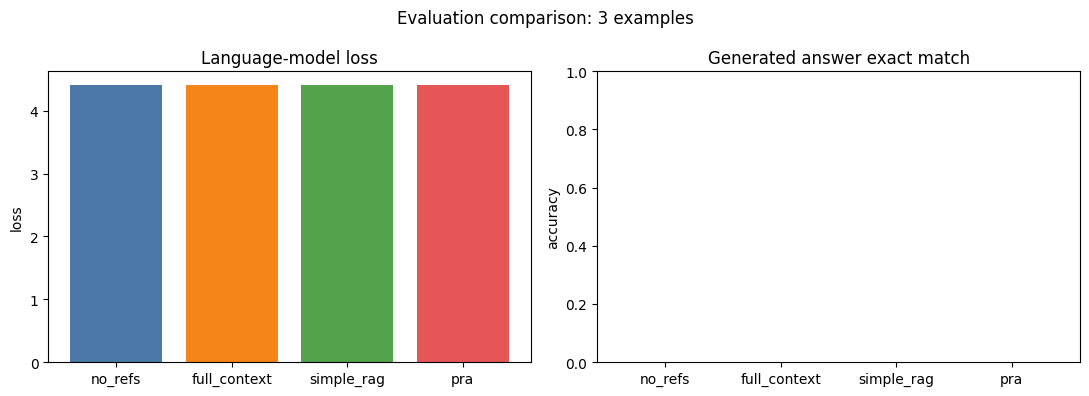

{'no_refs': 0.0, 'full_context': 0.0, 'simple_rag': 0.0, 'pra': 0.0}

In [23]:
default_evaluation_accuracy = plot_evaluation(
    default_evaluation,
    DEFAULT_SIZE,
    write_to_disk=WRITE_IMAGES_TO_DISK,
    run_dir=default_result["state"].run_dir,
)
default_evaluation_accuracy

## Additional Dataset-Size Workloads

Set `RUN_SCALING_EXPERIMENTS = True` in the controls cell and run the cells below.
Each cell is independent and retains its result for comparison. The 30,000-example run
is intentionally opt-in because it is a real multi-epoch CUDA workload and can take
substantial time on older GPUs.

A larger model is not automatically better. Compare held-out loss and answer accuracy
below: if training loss keeps falling while validation loss rises, reduce capacity or
epochs; if both remain high, increase epochs first, then capacity. The schedule above is
a conservative starting point, not a claim of optimal hyperparameters.

Calibration on this CUDA runtime showed why update count matters. At size 30, 45 updates
reduced test loss only to about 3.37; 120 updates reduced it to about 2.60 without a
train/validation divergence. At size 300, the wider model reached validation/test losses
near 1.38/1.43 after 120 updates and began producing exact validation answers, while its
curve was still descending. The final policy therefore uses 120 updates for size 30 and
180 for size 300. The larger workloads naturally receive about 375 and 2,250 updates.

In [24]:
def run_optional_workload(size, settings, enabled=False):
    if not enabled:
        print(f"Skipped size={size:,}; set RUN_SCALING_EXPERIMENTS = True to train it.")
        return None
    result = train_synthetic_workload(size, settings)
    plot_training_progress(result, write_to_disk=settings["write_images_to_disk"])
    return result

In [25]:
result_30 = run_optional_workload(30, settings, RUN_SCALING_EXPERIMENTS)

Skipped size=30; set RUN_SCALING_EXPERIMENTS = True to train it.


In [26]:
result_300 = run_optional_workload(300, settings, RUN_SCALING_EXPERIMENTS)

Skipped size=300; set RUN_SCALING_EXPERIMENTS = True to train it.


In [27]:
result_3000 = run_optional_workload(3_000, settings, RUN_SCALING_EXPERIMENTS)

Skipped size=3,000; set RUN_SCALING_EXPERIMENTS = True to train it.


In [28]:
result_30000 = run_optional_workload(30_000, settings, RUN_SCALING_EXPERIMENTS)

Skipped size=30,000; set RUN_SCALING_EXPERIMENTS = True to train it.


## Compare Capacity, Optimization, And Held-Out Performance

In [29]:
def compare_workloads(results):
    rows = []
    for result in results:
        if result is None:
            continue
        test_metrics = result["test_metrics"]
        rows.append(
            {
                "size": result["size"],
                "parameters": result["parameter_count"],
                "epochs": result["policy"]["epochs"],
                "optimizer_steps": result["global_step"],
                "train_loss": result["train_metrics"].get("train_loss"),
                "validation_loss": result["val_metrics"].get("loss"),
                "test_loss": test_metrics.get("loss"),
                "test_answer_accuracy": test_metrics.get("answer_accuracy"),
                "test_reference_accuracy": test_metrics.get("reference_retrieval_accuracy"),
            }
        )
    return rows

In [30]:
scaling_comparison = compare_workloads(
    [default_result, result_30, result_300, result_3000, result_30000]
)
scaling_comparison

[{'size': 3,
  'parameters': 37440,
  'epochs': 20,
  'optimizer_steps': 20,
  'train_loss': 2.2073721885681152,
  'validation_loss': 4.43203067779541,
  'test_loss': 4.404819488525391,
  'test_answer_accuracy': 0.0,
  'test_reference_accuracy': 0.0}]